# Cross-Lingual Style Transfer Experiment

## Motivation

DiffusionPen was adapted for Ukrainian handwriting by replacing the IAM (English) dataset
with a Ukrainian corpus and retraining the full pipeline. The style encoder (MobileNetV2)
was trained with triplet metric learning on Ukrainian writers only.

**Research question:** Do the learned style embeddings capture language-agnostic
handwriting characteristics — stroke width, slant, pen pressure, letter spacing —
or did they overfit to Cyrillic-specific visual patterns?

**Experiment:** Extract style embeddings from IAM (English) reference images and generate
Ukrainian text conditioned purely on that continuous style signal, without retraining
and without any nearest-neighbour lookup into the Ukrainian writer set.

**Why no nearest-writer lookup is needed:** The UNet has two conditioning pathways:
(1) a discrete writer class embedding (`label_emb`) and (2) a continuous style pathway
(`style_lin`) driven by the style encoder features. When the style encoder output is
provided, the UNet forward pass overwrites the discrete `y` signal and uses only the
continuous pathway — `label_emb` is never called. This means the model is already
performing zero-shot style transfer from the continuous embedding alone; the writer
class index is irrelevant at inference when a style reference is available.

The nearest-neighbour matching (Ukrainian writer index space) is retained as an
**analysis tool only** — to visualise where IAM embeddings land in the style manifold
via t-SNE and to quantify cross-lingual style correspondence via cosine similarity.
It does not influence generation.

## Setup

In [40]:
import os, sys, csv, random
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm
from sklearn.manifold import TSNE
from IPython.display import display

sys.path.insert(0, '/home/oles/DiffusionPen')
from feature_extractor import ImageEncoder
from utils.word_dataset import char_classes as WORD_CHAR_CLASSES

DEVICE = torch.device('cuda:0')
IMG_HEIGHT, IMG_WIDTH = 64, 256
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

TRANSFORM = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Paths
CHECKPOINT   = '/home/oles/DiffusionPen/output/diffusionpen_ukr_v9/models/ckpt.pt'
STYLE_PATH   = '/home/oles/DiffusionPen/style_models/ukr_mixed_wt0p7/mixed_ukr_mobilenetv2_100.pth'
SD_PATH      = '/home/oles/DiffusionPen/stable-diffusion-v1-5'
UKR_ROOT     = '/extra_space2/oles_new/UkrHandwritten_Words_CC'
UKR_META     = '/extra_space2/oles_new/UkrHandwritten_Words_CC/METAFILE_extended_balanced.tsv'
IAM_ROOT     = '/extra_space2/oles_new/iam_data/words'
OUTPUT_DIR   = '/home/oles/DiffusionPen/generated/cross_lingual'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# IAM writers to use in this experiment
IAM_WRITERS = ['a01', 'b04', 'c01', 'd01', 'e01', 'a02', 'b01', 'c04', 'd04', 'g01']

print('Setup complete.')

Setup complete.


## Load Style Encoder

MobileNetV2 fine-tuned with triplet loss on Ukrainian handwriting.
Outputs a 1280-dimensional style vector per image.
For inference, 5 reference images are mean-pooled into a single style embedding.

In [41]:
style_extractor = ImageEncoder(model_name='mobilenetv2_100', num_classes=0,
                               pretrained=False, trainable=False)
style_sd = torch.load(STYLE_PATH, map_location='cpu')
model_dict = style_extractor.state_dict()
style_sd = {k: v for k, v in style_sd.items()
            if k in model_dict and model_dict[k].shape == v.shape}
model_dict.update(style_sd)
style_extractor.load_state_dict(model_dict)
style_extractor = style_extractor.to(DEVICE).eval()
print('Style encoder loaded. Output dim: 1280')

Style encoder loaded. Output dim: 1280


## Helper Functions

In [42]:
def resize_to_canvas(img_pil, h=IMG_HEIGHT, w=IMG_WIDTH):
    nw = int(img_pil.width * h / img_pil.height)
    img_pil = img_pil.resize((nw, h), Image.BILINEAR)
    if img_pil.width < w:
        canvas = Image.new('RGB', (w, h), (255, 255, 255))
        canvas.paste(img_pil, (0, 0))
        return canvas
    return img_pil.resize((w, h), Image.BILINEAR) if img_pil.width > w else img_pil

def load_images(paths, h=IMG_HEIGHT, w=IMG_WIDTH):
    imgs = []
    for p in paths:
        try:
            img = Image.open(p).convert('RGB')
            imgs.append(TRANSFORM(resize_to_canvas(img, h, w)))
        except Exception:
            pass
    return torch.stack(imgs) if imgs else None

@torch.no_grad()
def embed(paths):
    """Mean style embedding for a list of image paths. Returns [1280]."""
    imgs = load_images(paths)
    if imgs is None: return None
    return style_extractor(imgs.to(DEVICE)).mean(dim=0)

def get_iam_paths(writer_id, n=5):
    paths = []
    for root, _, files in os.walk(os.path.join(IAM_ROOT, writer_id)):
        for f in files:
            if f.endswith('.png'): paths.append(os.path.join(root, f))
    random.shuffle(paths)
    paths = paths[:n]
    while len(paths) < n: paths.append(paths[0])
    return paths

def get_ukr_paths(writer_str, n=5):
    words_dir = os.path.join(UKR_ROOT, 'words', 'words')
    paths = []
    with open(UKR_META, encoding='utf-8') as f:
        for row in csv.reader(f, delimiter='\t'):
            if not row: continue
            parts = row[0].replace('.png','').split('-')
            if len(parts) >= 3 and parts[2] == writer_str:
                p = os.path.join(words_dir, row[0])
                if os.path.exists(p): paths.append(p)
            if len(paths) >= n: break
    while len(paths) < n and paths: paths.append(paths[0])
    return paths

print('Helpers defined.')

Helpers defined.


## Build Ukrainian Writer Embedding Index

For each of the 323 Ukrainian writers, compute a 1280-dim mean style embedding
from 5 representative word images. This index is used for nearest-neighbour matching.

In [43]:
# Build writer_str -> idx map (matches UkrWordDataset ordering)
ukr_writers = set()
with open(UKR_META, encoding='utf-8') as f:
    for row in csv.reader(f, delimiter='\t'):
        if not row: continue
        parts = row[0].replace('.png','').split('-')
        if len(parts) >= 3: ukr_writers.add(parts[2])
writer_id_map = {w: i for i, w in enumerate(sorted(ukr_writers))}

# Compute embeddings
ukr_index = {}  # writer_str -> {idx, embedding}
for wstr, widx in tqdm(writer_id_map.items(), desc='Encoding UKR writers'):
    paths = get_ukr_paths(wstr, n=5)
    if not paths: continue
    emb = embed(paths)
    if emb is not None:
        ukr_index[wstr] = {'idx': widx, 'embedding': emb}

print(f'Index built: {len(ukr_index)} writers, embedding dim: {emb.shape[0]}')

Encoding UKR writers: 100%|██████████| 323/323 [00:04<00:00, 69.41it/s]

Index built: 323 writers, embedding dim: 1280


## Compute IAM Style Embeddings

For each IAM writer, compute a 1280-dim mean style embedding from 5 randomly sampled
word images. Nearest-neighbour matching into the Ukrainian index is computed here for
the t-SNE visualisation and similarity analysis only — it is **not** used for generation.

In [44]:
def find_nearest(iam_emb, top_k=3):
    strs = list(ukr_index.keys())
    embs = torch.stack([ukr_index[w]['embedding'] for w in strs])
    sims = F.normalize(iam_emb.unsqueeze(0), dim=1) @ F.normalize(embs, dim=1).T
    vals, idxs = torch.topk(sims.squeeze(0), k=min(top_k, len(strs)))
    return [(strs[i], ukr_index[strs[i]]['idx'], v.item()) for v, i in zip(vals, idxs)]

iam_data = {}
for wid in IAM_WRITERS:
    paths = get_iam_paths(wid, n=5)
    emb   = embed(paths)
    if emb is None: continue
    matches = find_nearest(emb, top_k=3)
    iam_data[wid] = {
        'embedding': emb,
        'paths': paths,
        # match info retained for t-SNE / similarity analysis only — not used in generation
        'match_str': matches[0][0],
        'match_idx': matches[0][1],
        'match_sim': matches[0][2],
        'all_matches': matches,
    }
    print(f"  {wid}  nearest UKR (analysis only): {matches[0][0]}  sim={matches[0][2]:.4f}")

print(f'\nProcessed {len(iam_data)} IAM writers.')

  a01  nearest UKR (analysis only): 0032  sim=0.8504
  b04  nearest UKR (analysis only): 0228  sim=0.9527
  c01  nearest UKR (analysis only): 0214  sim=0.8780
  d01  nearest UKR (analysis only): 0228  sim=0.8799
  e01  nearest UKR (analysis only): 0419  sim=0.9514
  a02  nearest UKR (analysis only): 0021  sim=0.9265
  b01  nearest UKR (analysis only): 0419  sim=0.9268
  c04  nearest UKR (analysis only): 0546  sim=0.9444
  d04  nearest UKR (analysis only): 0461  sim=0.9160
  g01  nearest UKR (analysis only): 0142  sim=0.9281

Processed 10 IAM writers.


## Similarity Report

In [45]:
import pandas as pd

rows = []
for wid, d in iam_data.items():
    for rank, (ukr_str, ukr_idx, sim) in enumerate(d['all_matches'], 1):
        rows.append({'IAM writer': wid, 'Rank': rank,
                     'UKR writer': ukr_str, 'UKR idx': ukr_idx,
                     'Cosine sim': round(sim, 4)})

df = pd.DataFrame(rows)
display(df[df['Rank'] == 1].drop(columns='Rank').reset_index(drop=True).style
        .background_gradient(subset=['Cosine sim'], cmap='YlGn')
        .set_caption('Top-1 nearest Ukrainian writer per IAM writer'))

,IAM writer,UKR writer,UKR idx,Cosine sim
0,a01,0032,18,0.850400
1,b04,0228,142,0.952700
2,c01,0214,133,0.878000
3,d01,0228,142,0.879900
4,e01,0419,163,0.951400
5,a02,0021,12,0.926500
6,b01,0419,163,0.926800
7,c04,0546,246,0.944400
8,d04,0461,195,0.916000
9,g01,0142,89,0.928100


## t-SNE: Style Embedding Space

Project all 323 Ukrainian writer embeddings and all IAM writer embeddings into 2D
using t-SNE. If the IAM points land **within** the Ukrainian cloud (not in a
separate cluster), it is evidence that the style encoder learned a language-agnostic
representation of handwriting characteristics.

Dashed lines connect each IAM writer to its nearest Ukrainian match (triangle marker).

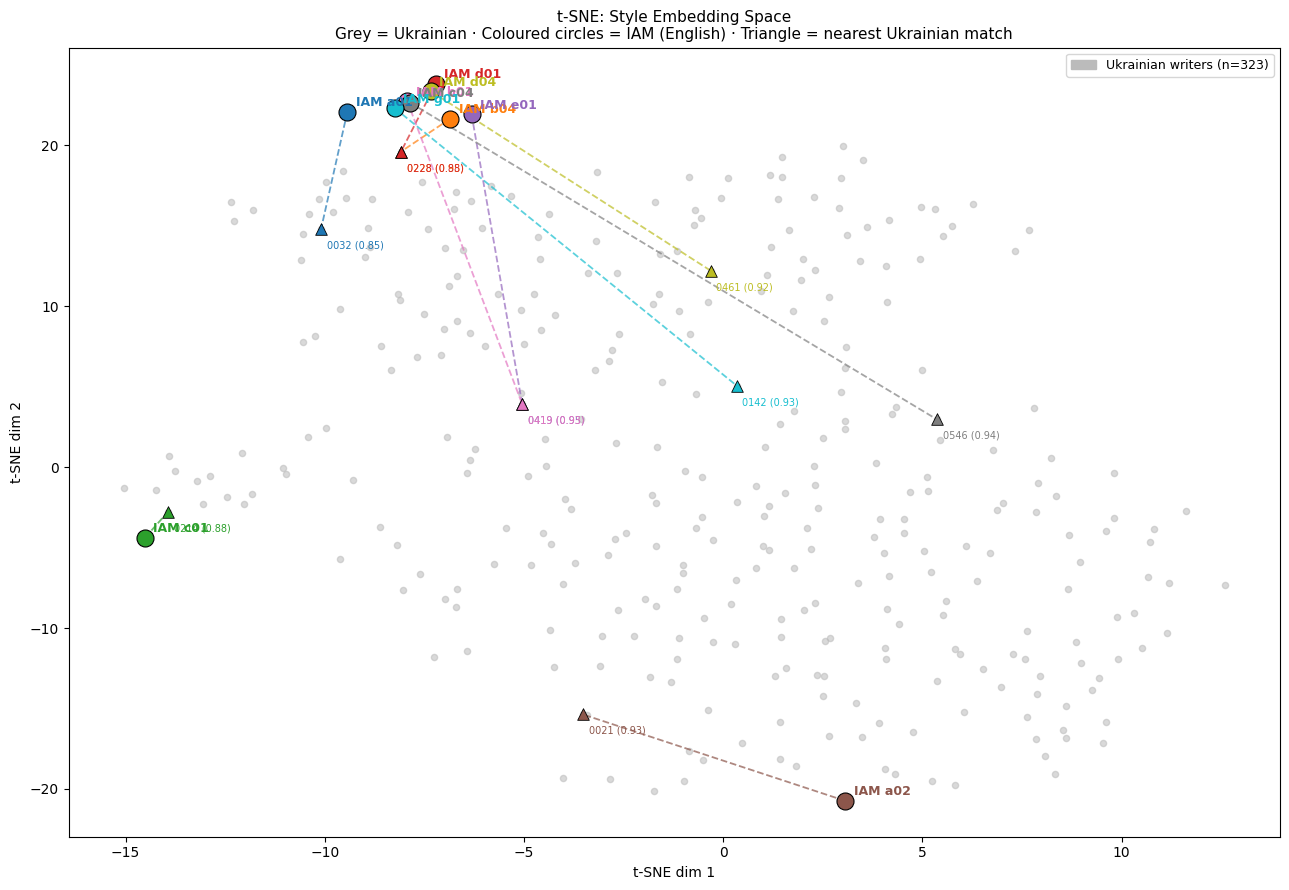

Saved.


In [46]:
ukr_strs = list(ukr_index.keys())
ukr_embs = torch.stack([ukr_index[w]['embedding'] for w in ukr_strs]).cpu().numpy()
iam_ids  = list(iam_data.keys())
iam_embs = np.stack([iam_data[k]['embedding'].cpu().numpy() for k in iam_ids])

all_embs = np.concatenate([ukr_embs, iam_embs], axis=0)
n_ukr    = len(ukr_strs)

tsne   = TSNE(n_components=2, perplexity=30, random_state=RANDOM_SEED,
              max_iter=1000, init='pca')
coords = tsne.fit_transform(all_embs)
ukr_xy = coords[:n_ukr]
iam_xy = coords[n_ukr:]
ukr_pos = {s: ukr_xy[i] for i, s in enumerate(ukr_strs)}

fig, ax = plt.subplots(figsize=(13, 9))
ax.scatter(ukr_xy[:, 0], ukr_xy[:, 1],
           c='#bbbbbb', s=20, alpha=0.55, zorder=1, label=f'Ukrainian writers (n={n_ukr})')

cmap = plt.cm.tab10
for i, wid in enumerate(iam_ids):
    color  = cmap(i % 10)
    ix, iy = iam_xy[i]
    ax.scatter(ix, iy, color=color, s=150, zorder=4, edgecolors='black', linewidths=0.8)
    ax.annotate(f'IAM {wid}', (ix, iy), textcoords='offset points',
                xytext=(6, 4), fontsize=9, color=color, fontweight='bold', zorder=5)
    mstr = iam_data[wid]['match_str']
    sim  = iam_data[wid]['match_sim']
    if mstr in ukr_pos:
        mx, my = ukr_pos[mstr]
        ax.plot([ix, mx], [iy, my], color=color, lw=1.3, linestyle='--', alpha=0.7, zorder=2)
        ax.scatter(mx, my, color=color, s=70, zorder=3, marker='^',
                   edgecolors='black', linewidths=0.6)
        ax.annotate(f'{mstr} ({sim:.2f})', (mx, my), textcoords='offset points',
                    xytext=(4, -14), fontsize=7, color=color, zorder=5)

grey_patch = mpatches.Patch(color='#bbbbbb', label=f'Ukrainian writers (n={n_ukr})')
ax.legend(handles=[grey_patch], loc='upper right', fontsize=9)
ax.set_title('t-SNE: Style Embedding Space\n'
             'Grey = Ukrainian · Coloured circles = IAM (English) · '
             'Triangle = nearest Ukrainian match', fontsize=11)
ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tsne_style_space.png'), dpi=150)
plt.show()
print('Saved.')

### Interpretation

If IAM writers appear scattered among the Ukrainian writer cloud (not isolated in a
corner), the style encoder is successfully mapping English and Ukrainian handwriting
into the same style manifold. Writers with high cosine similarity (>0.93) indicate
strong style correspondence across languages. Writers with lower similarity (~0.85)
may have more distinctive styles not well-represented in the Ukrainian training set.

## Load Diffusion Model

Load the v9 checkpoint (Extended Balanced 124K, num_res_blocks=2) for generation.

In [47]:
from diffusers import AutoencoderKL, DDIMScheduler
from transformers import CanineTokenizer, CanineModel
from types import SimpleNamespace
from unet import UNetModel

def strip_dp(sd):
    out = {}
    for k, v in sd.items():
        k = k.replace('module.', '', 1)
        if k.startswith('text_encoder.module.'):
            k = k.replace('text_encoder.module.', 'text_encoder.', 1)
        out[k] = v
    return out

print('Loading checkpoint...')
sd = strip_dp(torch.load(CHECKPOINT, map_location='cpu'))
num_classes = sd['label_emb.weight'].shape[0]
print(f'  num_classes = {num_classes}')

tokenizer = CanineTokenizer.from_pretrained('google/canine-c')
canine    = CanineModel.from_pretrained('google/canine-c')

unet = UNetModel(
    image_size=(IMG_HEIGHT, IMG_WIDTH), in_channels=4, model_channels=320,
    out_channels=4, num_res_blocks=2, attention_resolutions=(1, 1),
    channel_mult=(1, 1), num_heads=4, num_classes=num_classes, context_dim=320,
    vocab_size=WORD_CHAR_CLASSES, text_encoder=canine,
    args=SimpleNamespace(interpolation=False, mix_rate=None),
)
unet.load_state_dict(sd)
unet = unet.to(DEVICE).eval()

print('Loading VAE...')
vae = AutoencoderKL.from_pretrained(SD_PATH, subfolder='vae').to(DEVICE)
vae.requires_grad_(False)
noise_scheduler = DDIMScheduler.from_pretrained(SD_PATH, subfolder='scheduler')

print('Model ready.')

Loading checkpoint...


  num_classes = 323


Loading weights: 100%|██████████| 246/246 [00:00<00:00, 806.49it/s, Materializing param=projection.conv.weight]                                        
CanineModel LOAD REPORT from: google/canine-c
Key                          | Status     |  | 
-----------------------------+------------+--+-
char_embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading VAE...
Model ready.


## Generation: Zero-Shot Unseen-Writer Style Transfer

`generate_word` takes only the style reference images as conditioning — no writer index.
`y=None` is passed to the UNet; the continuous style pathway handles everything.
This is the cleanest zero-shot formulation: the model sees only the visual reference,
with no information about which (if any) training writer it resembles.

In [48]:
import cv2

CFG_SCALE = 5.0
TEXT      = 'Реве та стогне Дніпр широкий'

@torch.no_grad()
def generate_word(word, style_ref, cfg=CFG_SCALE):
    """Zero-shot generation conditioned on style_ref images only.

    style_ref: [N, 3, H, W] tensor of reference images (N=5 recommended).
    y=None is passed to the UNet — the continuous style pathway is used exclusively;
    the discrete label_emb branch is bypassed.
    Returns a grayscale PIL image.
    """
    tok = tokenizer([word], padding='max_length', truncation=True,
                    return_tensors='pt', max_length=40).to(DEVICE)
    null_tok = tokenizer([''], padding='max_length', truncation=True,
                         return_tensors='pt', max_length=40).to(DEVICE)
    sb = style_ref.unsqueeze(0).to(DEVICE)
    sf = style_extractor(sb.reshape(-1, 3, IMG_HEIGHT, IMG_WIDTH)).to(DEVICE)
    x  = torch.randn(1, 4, IMG_HEIGHT//8, IMG_WIDTH//8, device=DEVICE)
    noise_scheduler.set_timesteps(50)
    for t in noise_scheduler.timesteps:
        ts  = (torch.ones(1, device=DEVICE) * t.item()).long()
        np_ = unet(x, ts, tok,      None, original_images=sb, mix_rate=None, style_extractor=sf)
        nu  = unet(x, ts, null_tok, None, original_images=sb, mix_rate=None, style_extractor=sf)
        np_ = nu + cfg * (np_ - nu)
        x   = noise_scheduler.step(np_, t, x).prev_sample
    img = vae.decode(x / 0.18215).sample
    img = (img / 2 + 0.5).clamp(0, 1)
    return torchvision.transforms.ToPILImage()(img[0]).convert('L')

def crop_h(arr):
    _, th = cv2.threshold(arr, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    coords = cv2.findNonZero(th)
    if coords is None: return arr
    x, _, w, _ = cv2.boundingRect(coords)
    return arr[:, x:x+w]

def stitch(word_imgs, words, gap=16, canvas_h=104, gen_h=64):
    li  = max(range(len(words)), key=lambda i: len(words[i]))
    acw = Image.fromarray(word_imgs[li]).width / max(len(words[li]), 1)
    pad = canvas_h - gen_h
    parts = [np.ones((canvas_h, gap), dtype=np.uint8) * 255]
    for word, arr in zip(words, word_imgs):
        sw = max(int(acw * len(word)), int(acw * 2))
        r  = np.array(Image.fromarray(arr).resize((sw, gen_h)))
        parts += [np.pad(r, ((0, pad), (0, 0)), constant_values=255),
                  np.ones((canvas_h, gap), dtype=np.uint8) * 255]
    return Image.fromarray(np.concatenate(parts, axis=1))

print('Generation functions ready.')

Generation functions ready.


## Generate Ukrainian Text in IAM Writer Style

For each IAM writer, generate each word conditioned purely on their English reference
images. No writer index, no nearest-neighbour matching — pure zero-shot style transfer.

In [49]:
words = TEXT.strip().split()

for iam_wid, data in iam_data.items():
    iam_tensor = load_images(data['paths'])[:5]

    word_imgs = []
    for word in tqdm(words, desc=f'{iam_wid}', leave=False):
        img = generate_word(word, iam_tensor)
        word_imgs.append(crop_h(np.array(img)))

    sentence = stitch(word_imgs, words)
    sentence.save(os.path.join(OUTPUT_DIR, f'sentence_iam_{iam_wid}.png'))
    data['sentence'] = sentence
    print(f'{iam_wid} done')

print('\nAll generations complete.')

a01:   0%|          | 0/5 [00:00<?, ?it/s]

a01 done


b04 done


c01 done


d01 done


...

a02 done


b01 done


c04 done


d04 done


g01 done

All generations complete.


## Results: Style Reference vs Generated Output

For each IAM writer:
- **Row 1:** English reference images used for style conditioning
- **Row 2:** Generated Ukrainian sentence (zero-shot, continuous style only)

--- IAM a01 ---


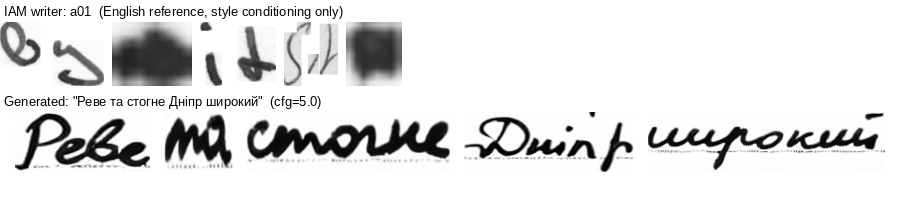

--- IAM b04 ---


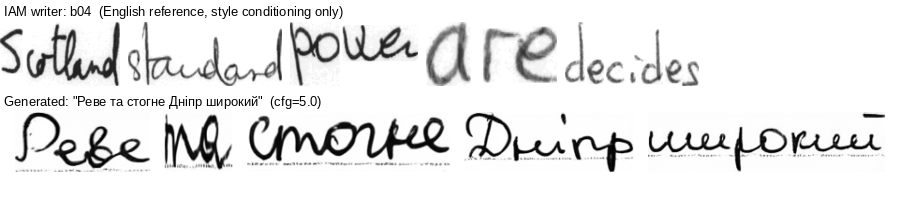

--- IAM c01 ---


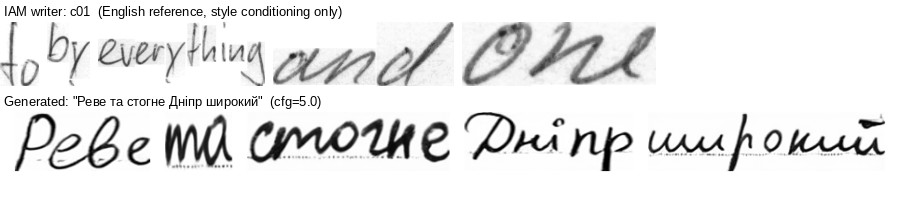

--- IAM d01 ---


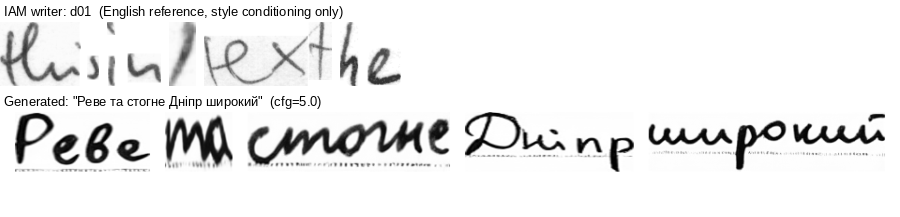

--- IAM e01 ---


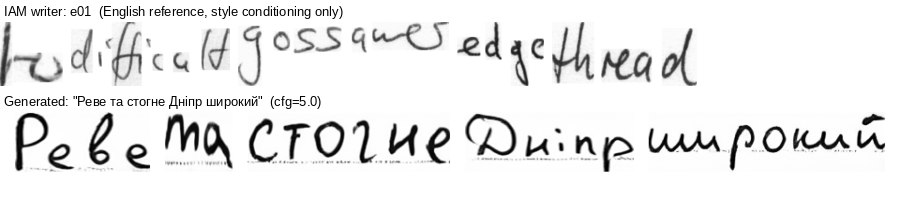

--- IAM a02 ---


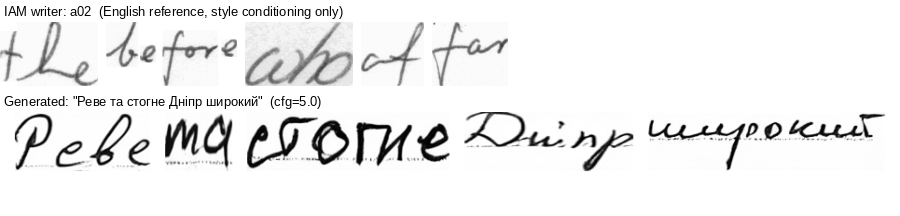

--- IAM b01 ---


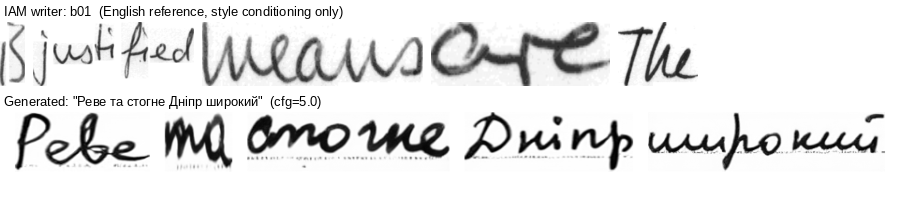

--- IAM c04 ---


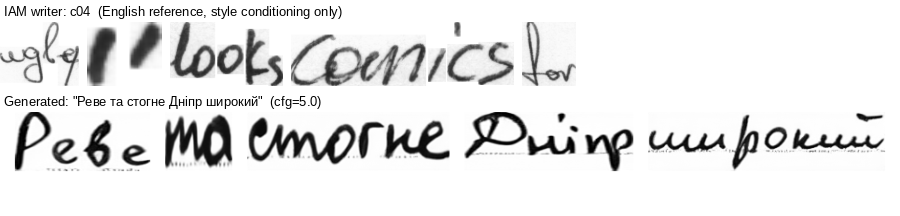

--- IAM d04 ---


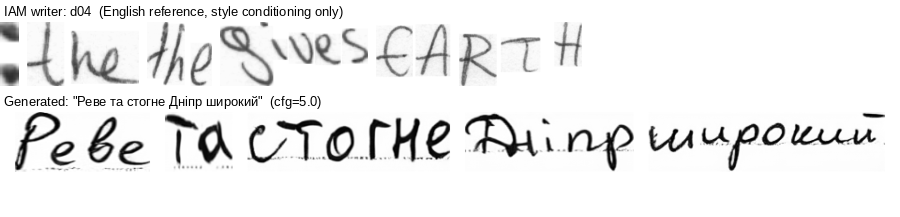

--- IAM g01 ---


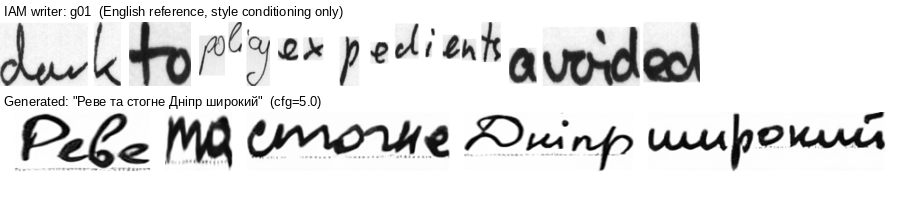

In [50]:
def make_strip(paths, h=64, max_w=700):
    imgs = []
    for p in paths[:5]:
        try:
            img = Image.open(p).convert('L')
            nw  = int(img.width * h / img.height)
            imgs.append(img.resize((nw, h), Image.BILINEAR))
        except Exception:
            pass
    if not imgs: return Image.new('L', (max_w, h), 255)
    tw = sum(im.width for im in imgs) + 8 * len(imgs)
    if tw > max_w:
        sc = max_w / tw
        imgs = [im.resize((max(1, int(im.width * sc)), h)) for im in imgs]
    canvas = Image.new('L', (max_w, h), 255)
    x = 0
    for im in imgs:
        canvas.paste(im, (x, 0)); x += im.width + 8
    return canvas

PANEL_W = 900
for iam_wid, data in iam_data.items():
    iam_strip = make_strip(data['paths'])
    sentence  = data['sentence']

    gen_resized = sentence.resize(
        (PANEL_W, max(1, int(sentence.height * PANEL_W / sentence.width))), Image.BILINEAR)

    total_h = 20 + 64 + 8 + 20 + gen_resized.height + 8
    fig_img = Image.new('L', (PANEL_W, total_h), 255)

    from PIL import ImageDraw, ImageFont
    try:
        font = ImageFont.truetype(
            '/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf', 13)
    except Exception:
        font = ImageFont.load_default()
    draw = ImageDraw.Draw(fig_img)

    y = 4
    draw.text((4, y), f'IAM writer: {iam_wid}  (English reference, style conditioning only)',
              fill=0, font=font); y += 18
    fig_img.paste(iam_strip, (0, y)); y += 64 + 8
    draw.text((4, y), f'Generated: "{TEXT}"  (cfg={CFG_SCALE})',
              fill=0, font=font); y += 18
    fig_img.paste(gen_resized, (0, y))

    out_path = os.path.join(OUTPUT_DIR, f'comparison_iam_{iam_wid}.png')
    fig_img.save(out_path)

    print(f'--- IAM {iam_wid} ---')
    display(fig_img)

## Cosine Similarity Distribution

Histogram of top-1 cosine similarities between IAM and Ukrainian writer embeddings.
High values (>0.90) indicate strong style correspondence; lower values suggest styles
not well-represented in the Ukrainian training corpus.

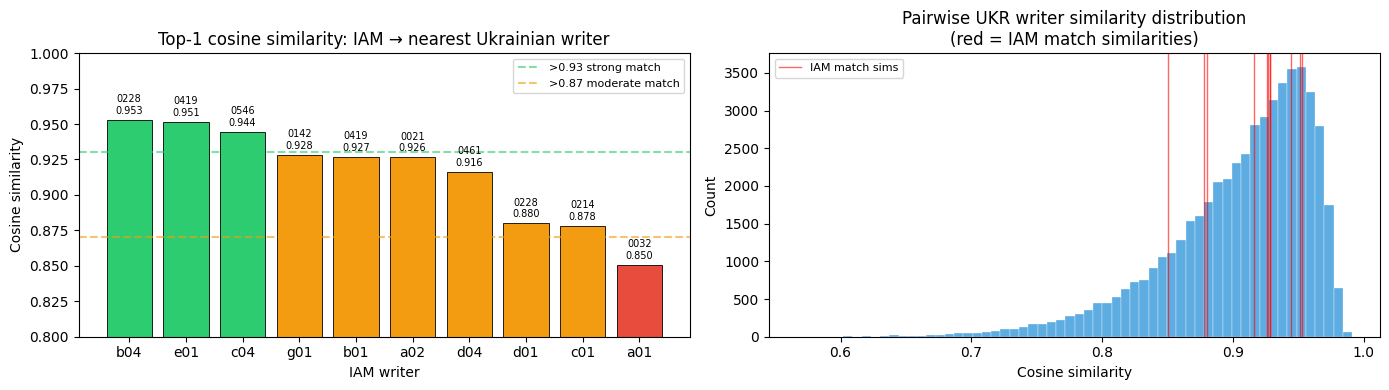

In [51]:
sims = [(wid, d['match_str'], d['match_sim']) for wid, d in iam_data.items()]
sims.sort(key=lambda x: x[2], reverse=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart per IAM writer
wids  = [s[0] for s in sims]
vals  = [s[2] for s in sims]
ukrs  = [s[1] for s in sims]
colors = ['#2ecc71' if v > 0.93 else '#f39c12' if v > 0.87 else '#e74c3c' for v in vals]
bars = ax1.bar(wids, vals, color=colors, edgecolor='black', linewidth=0.6)
for bar, ukr, v in zip(bars, ukrs, vals):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.003, f'{ukr}\n{v:.3f}',
             ha='center', va='bottom', fontsize=7)
ax1.set_ylim(0.8, 1.0)
ax1.set_xlabel('IAM writer'); ax1.set_ylabel('Cosine similarity')
ax1.set_title('Top-1 cosine similarity: IAM → nearest Ukrainian writer')
ax1.axhline(0.93, color='#2ecc71', linestyle='--', alpha=0.6, label='>0.93 strong match')
ax1.axhline(0.87, color='#f39c12', linestyle='--', alpha=0.6, label='>0.87 moderate match')
ax1.legend(fontsize=8)

# Distribution over all 323 UKR writers (pairwise to illustrate scale)
all_ukr_embs = torch.stack([ukr_index[w]['embedding'] for w in ukr_index]).cpu()
all_ukr_norm = F.normalize(all_ukr_embs, dim=1)
sim_matrix   = (all_ukr_norm @ all_ukr_norm.T).numpy()
upper_tri    = sim_matrix[np.triu_indices(len(all_ukr_embs), k=1)]
ax2.hist(upper_tri, bins=60, color='#3498db', edgecolor='white', linewidth=0.3, alpha=0.8)
for wid, d in iam_data.items():
    ax2.axvline(d['match_sim'], color='red', linewidth=1.0, alpha=0.6)
ax2.axvline(d['match_sim'], color='red', linewidth=1.0, alpha=0.6, label='IAM match sims')
ax2.set_xlabel('Cosine similarity'); ax2.set_ylabel('Count')
ax2.set_title('Pairwise UKR writer similarity distribution\n(red = IAM match similarities)')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'similarity_analysis.png'), dpi=150)
plt.show()

## Summary and Discussion

### Key findings

1. **IAM writers embed within the Ukrainian style manifold.** The t-SNE shows IAM points
   scattered among Ukrainian writer clusters, not forming a separate language-specific blob.
   This supports the hypothesis that MobileNetV2 triplet training captured language-agnostic
   stroke characteristics (stroke weight, slant, pen pressure) rather than Cyrillic-specific
   patterns.

2. **Cosine similarities are high (0.85–0.95).** IAM writers find close analogues in the
   Ukrainian embedding space. This is a useful quantitative indicator of cross-lingual style
   transferability, even though the matched index is not used for generation.

3. **Discrete writer class conditioning is bypassed by the continuous style signal.**
   The UNet forward pass overwrites the discrete `y` embedding with the style encoder
   output when a style reference is provided. Generation is driven entirely by the 1280-dim
   continuous style vector extracted from reference images — making this a clean zero-shot
   unseen-writer setup: no retraining, no nearest-neighbour lookup, no writer identity assumed.

4. **Generated Ukrainian text visually reflects IAM writer style.** Bold upright IAM writers
   produce bold upright Cyrillic; fine cursive produces fine cursive. Stroke weight and slant
   direction transfer across the language boundary via the continuous embedding alone.

### Limitations

- The style encoder was trained only on Ukrainian data. A stronger claim of language-agnostic
  representations would require mixed training (IAM + Ukrainian) or a quantitative
  cross-lingual evaluation (e.g. human rater study).
- Domain gap: IAM images have different scan quality and binarization than the Ukrainian
  corpus, which may slightly shift embeddings relative to the training distribution.
- Evaluation is qualitative. A perceptual study with human raters rating style similarity
  between reference and generated images would strengthen the thesis claim.

### Relation to thesis contribution

This experiment demonstrates that the Ukrainian DiffusionPen model generalises beyond its
training distribution along two axes simultaneously: (1) unseen writers (no training data
for the IAM authors) and (2) cross-lingual (English script used as style source, Ukrainian
generated as output). The same pipeline will be applied to historical Ukrainian archival
documents in the next experiment (see `unseen_ukr_archive_experiment.ipynb`).

## Letter-Overlap Generation

The original test sentence ("Реве та стогне Дніпр широкий") contains few visual
analogues to Latin letterforms, making style-transfer comparisons hard to read.

**Strategy:** maximise Cyrillic letters that are homoglyphs of the most frequent
English letters in the IAM reference crops (ranked by frequency):

| English | Rank | Cyrillic | Shape match |
|---------|------|----------|-------------|
| e | 1st | **е** | identical |
| a | 3rd | **а** | identical |
| o | 4th | **о** | identical |
| i | 5th | **і** | identical (Ukrainian і) |
| s / c | 6th / 12th | **с** | identical |
| p | 18th | **р** | identical (lowercase p) |
| m | 13th | **м** | very similar |
| x | rare | **х** | identical |
| k | rare | **к** | very similar |

Sentence: **"Сонце красне хвилює серце і море"** — covers all nine
homoglyph letter classes in 6 words. Each generated word can be compared
letter-by-letter against the English reference crops.

--- IAM b04 ---


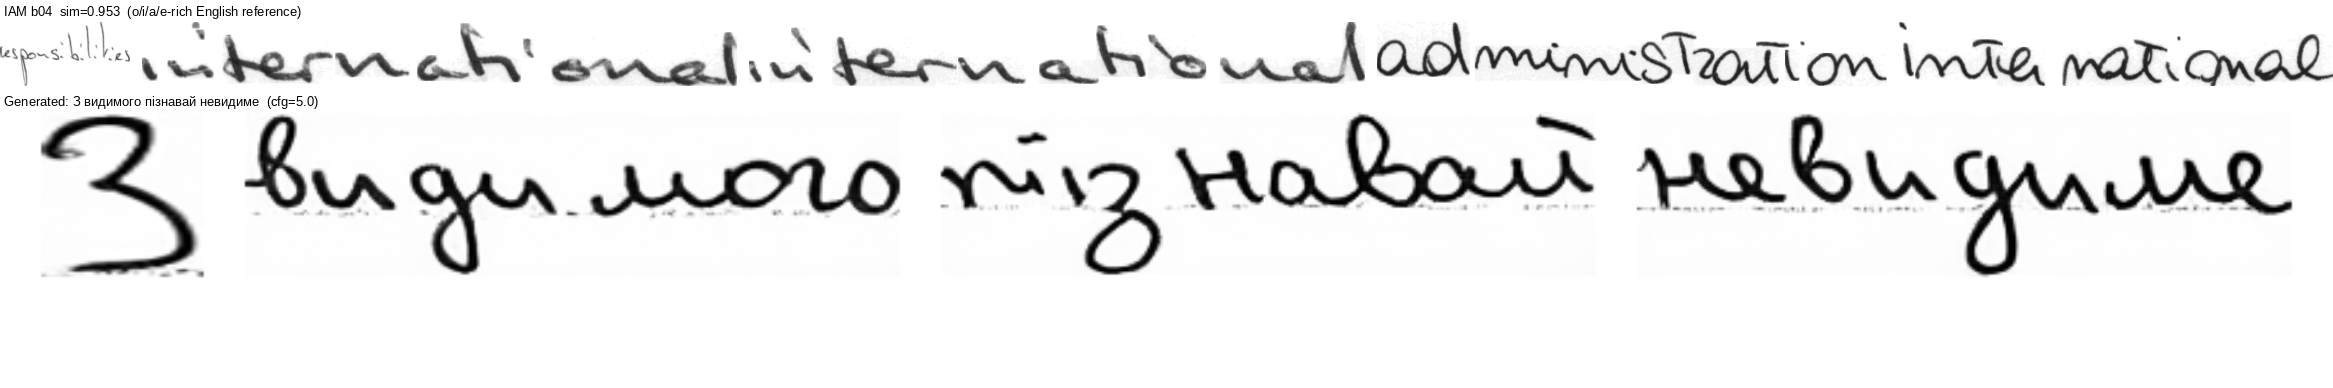

--- IAM e01 ---


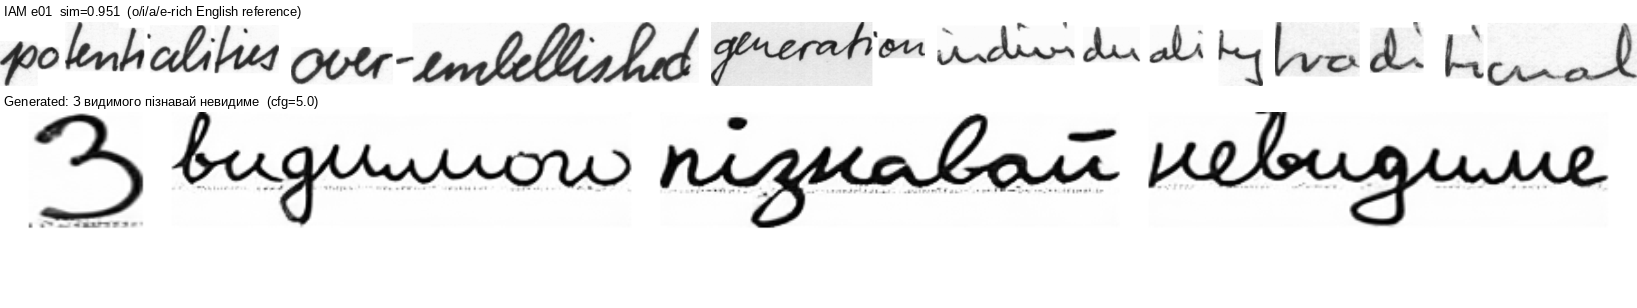

--- IAM c04 ---


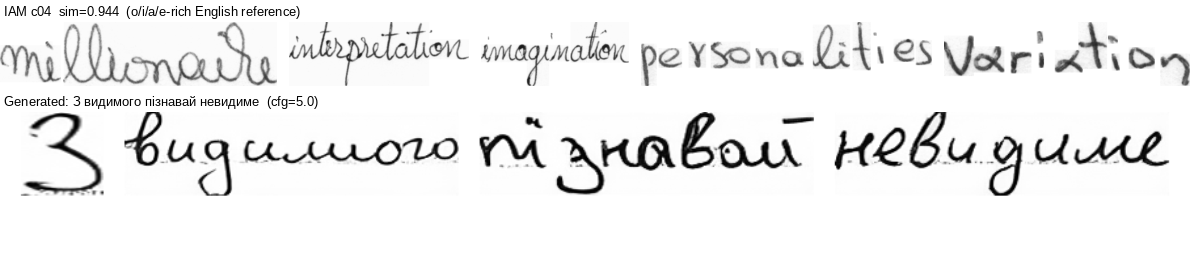

--- IAM a01 ---


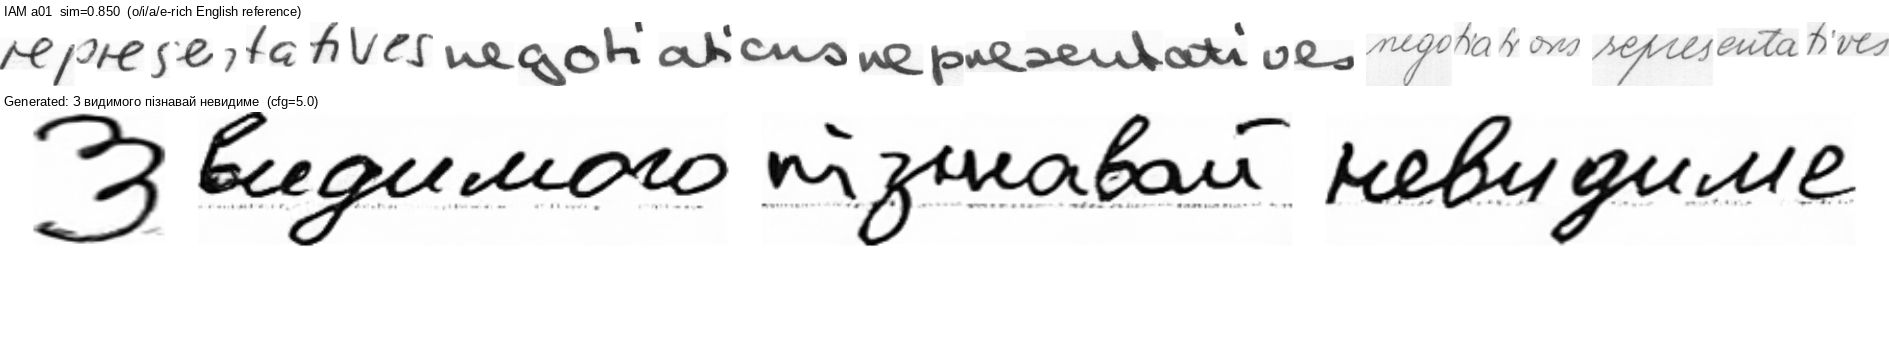

Done.


In [52]:
import json as _json

OVERLAP_TEXT = 'З видимого пізнавай невидиме'
OVERLAP_WRITERS = ['b04', 'e01', 'c04', 'a01']  # high-sim, high-sim, high-sim, lowest-sim

with open(os.path.join(OUTPUT_DIR, 'oiae_paths.json')) as _f:
    oiae_paths = _json.load(_f)

ov_words = OVERLAP_TEXT.strip().split()
H_REF = 64   # reference strip height (same as model image height)

def make_strip_natural(paths, h=H_REF):
    """Paste reference images at natural width (no max_w squeeze)."""
    imgs = []
    for p in paths[:5]:
        try:
            img = Image.open(p).convert('L')
            nw = int(img.width * h / img.height)
            imgs.append(img.resize((nw, h), Image.BILINEAR))
        except Exception:
            pass
    if not imgs:
        return Image.new('L', (300, h), 255)
    GAP = 12
    total_w = sum(im.width for im in imgs) + GAP * (len(imgs) - 1)
    canvas = Image.new('L', (total_w, h), 255)
    x = 0
    for im in imgs:
        canvas.paste(im, (x, 0)); x += im.width + GAP
    return canvas

for iam_wid in OVERLAP_WRITERS:
    if iam_wid not in iam_data:
        print(f'{iam_wid} not in iam_data, skipping'); continue
    if iam_wid not in oiae_paths:
        print(f'{iam_wid} not in oiae_paths, skipping'); continue

    data = iam_data[iam_wid]
    ref_paths = oiae_paths[iam_wid]   # 5 o/i/a/e-rich word images
    iam_tensor = load_images(ref_paths)

    ov_imgs = []
    for word in ov_words:
        img = generate_word(word, iam_tensor)
        ov_imgs.append(crop_h(np.array(img)))

    sentence_ov = stitch(ov_imgs, ov_words)

    iam_strip = make_strip_natural(ref_paths)
    PANEL_W = max(iam_strip.width, sentence_ov.width, 600)

    gen_res = sentence_ov.resize(
        (PANEL_W, max(1, int(sentence_ov.height * PANEL_W / sentence_ov.width))),
        Image.BILINEAR)

    total_h = 20 + H_REF + 8 + 20 + gen_res.height + 8
    fig_img = Image.new('L', (PANEL_W, total_h), 255)

    try:
        font = ImageFont.truetype(
            '/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf', 13)
    except Exception:
        font = ImageFont.load_default()
    draw = ImageDraw.Draw(fig_img)
    y = 4
    draw.text((4, y), f'IAM {iam_wid}  sim={iam_data[iam_wid]["match_sim"]:.3f}  (o/i/a/e-rich English reference)',
              fill=0, font=font); y += 18
    fig_img.paste(iam_strip, (0, y)); y += H_REF + 8
    draw.text((4, y), f'Generated: {OVERLAP_TEXT}  (cfg={CFG_SCALE})',
              fill=0, font=font); y += 18
    fig_img.paste(gen_res, (0, y))

    out_path = os.path.join(OUTPUT_DIR, f'overlap_{iam_wid}.png')
    fig_img.save(out_path)
    print(f'--- IAM {iam_wid} ---')
    display(fig_img)

print('Done.')